In [1]:
import os
import numpy as np
import pandas as pd
import pandas_market_calendars as mcal
import datetime as dt
from data_processor import DataReader, DataPrep
from scipy import stats
import pandas_ta as ta
from matplotlib import pyplot as plt
from scipy.stats import norm
from scipy import stats
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.stattools import adfuller
pd.set_option('display.float_format', '{:.10f}'.format)

### EDA

In [2]:
# daily_data_path = r'data/daily_data'
# intraday_data_path = r'data/intraday_data'
# intraday_df = DataReader.read_intraday_data(intraday_data_path)
# daily_df = DataReader.read_daily_data(daily_data_path)
# intraday_df.to_pickle('intraday_df.pkl')
# daily_df.to_pickle('daily_df.pkl')

In [3]:
daily_df = pd.read_pickle('daily_df.pkl')
intraday_df =  pd.read_pickle('intraday_df.pkl')
data_prep = DataPrep(intraday_df, daily_df)
target_df = data_prep.get_target(clip_MAD=True, normalize= True)
X_df = data_prep.get_features()
input_data = X_df.join(target_df[['y', 'y_actual_clipped']], how = 'right')

## Features

#### Volume

<Axes: >

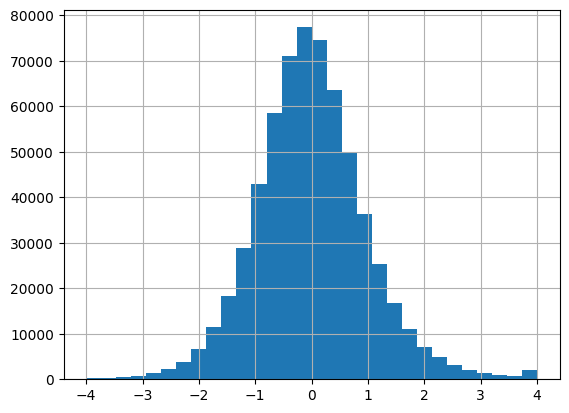

In [4]:
input_data.VolumeChangeNormalize.hist(bins = 30)

#### Intraday RSI

<Axes: >

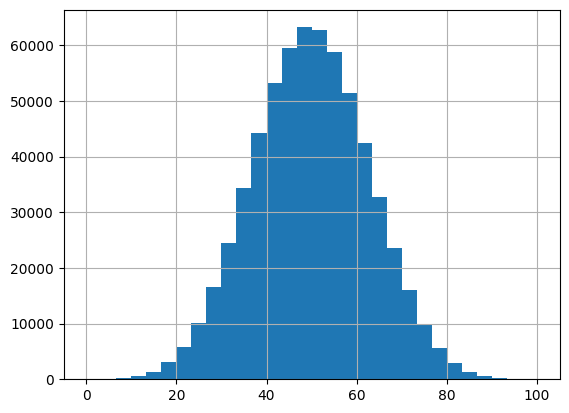

In [5]:
input_data.IntradayRSI.hist(bins = 30)

In [6]:
clipped_returns = [col for col in input_data.columns if 'clipped' in col and 'Return' in col]
features = clipped_returns + ['VolumeChangeNormalize', 'IntradayRSI']

In [7]:
input_data[features + ['y']].corr()

,Rolling_Return_1d_clipped,Rolling_Return_2d_clipped,Rolling_Return_3d_clipped,Rolling_Return_4d_clipped,Rolling_Return_5d_clipped,Rolling_Return_6d_clipped,Rolling_Return_7d_clipped,Rolling_Return_8d_clipped,Rolling_Return_9d_clipped,Rolling_Return_10d_clipped,...,Rolling_Return_15d_clipped,Rolling_Return_16d_clipped,Rolling_Return_17d_clipped,Rolling_Return_18d_clipped,Rolling_Return_19d_clipped,Rolling_Return_20d_clipped,CumReturnResid_clipped,VolumeChangeNormalize,IntradayRSI,y
Rolling_Return_1d_clipped,1.0000000000,0.7048950602,0.5756629496,0.4985346020,0.4448027168,0.4060177592,0.3756914207,0.3512575145,0.3303598503,0.3123920056,...,0.2542140982,0.2459412674,0.2382152402,0.2313206840,0.2240868744,0.2180818651,-0.0027878081,-0.0312792265,0.0026638562,-0.0006381710
Rolling_Return_2d_clipped,0.7048950602,1.0000000000,0.8148347310,0.7057476253,0.6307658233,0.5752984871,0.5326673916,0.4982085943,0.4692407428,0.4440589446,...,0.3609426518,0.3492318117,0.3383706900,0.3284370915,0.3188518906,0.3098633496,-0.0013218281,-0.0309568239,0.0001317641,0.0006233151
Rolling_Return_3d_clipped,0.5756629496,0.8148347310,1.0000000000,0.8645387771,0.7727981149,0.7051924146,0.6526264247,0.6106509384,0.5753968855,0.5449820142,...,0.4423985125,0.4282207976,0.4150280582,0.4028792074,0.3912624081,0.3805464349,-0.0011431770,-0.0257897274,0.0013763130,0.0005836055
Rolling_Return_4d_clipped,0.4985346020,0.7057476253,0.8645387771,1.0000000000,0.8927546002,0.8145849455,0.7540542089,0.7052618783,0.6649015935,0.6300898082,...,0.5116394032,0.4947571437,0.4797240892,0.4657814154,0.4525606155,0.4402378873,-0.0017253331,-0.0231724299,0.0023368209,0.0015861641
Rolling_Return_5d_clipped,0.4448027168,0.6307658233,0.7727981149,0.8927546002,1.0000000000,0.9113580376,0.8435490761,0.7891171843,0.7437736300,0.7052697278,...,0.5726624212,0.5539588984,0.5367620268,0.5213450877,0.5066954394,0.4930488244,-0.0008667782,-0.0200054417,0.0022809637,0.0020999435
Rolling_Return_6d_clipped,0.4060177592,0.5752984871,0.7051924146,0.8145849455,0.9113580376,1.0000000000,0.9246423436,0.8647530080,0.8152098134,0.7728953844,...,0.6277973408,0.6072790603,0.5886164600,0.5713733303,0.5555184822,0.5406725469,-0.0000748789,-0.0185881852,0.0029795391,0.0018566790
Rolling_Return_7d_clipped,0.3756914207,0.5326673916,0.6526264247,0.7540542089,0.8435490761,0.9246423436,1.0000000000,0.9343378991,0.8806021340,0.8350093122,...,0.6785500896,0.6561835086,0.6359972490,0.6175130999,0.6001477664,0.5842743524,0.0000876087,-0.0172401235,0.0022472441,0.0018223282
Rolling_Return_8d_clipped,0.3512575145,0.4982085943,0.6106509384,0.7052618783,0.7891171843,0.8647530080,0.9343378991,1.0000000000,0.9417472895,0.8928083316,...,0.7259061585,0.7018712662,0.6801160095,0.6603470125,0.6419315564,0.6247111157,-0.0000350853,-0.0164964089,0.0016421060,0.0009851504
Rolling_Return_9d_clipped,0.3303598503,0.4692407428,0.5753968855,0.6649015935,0.7437736300,0.8152098134,0.8806021340,0.9417472895,1.0000000000,0.9474405955,...,0.7704459989,0.7450664876,0.7218762807,0.7007449396,0.6812322925,0.6631033225,-0.0006397937,-0.0154102806,0.0012685785,0.0012658982
Rolling_Return_10d_clipped,0.3123920056,0.4440589446,0.5449820142,0.6300898082,0.7052697278,0.7728953844,0.8350093122,0.8928083316,0.9474405955,1.0000000000,...,0.8126995864,0.7860437590,0.7616909755,0.7392992335,0.7185807178,0.6995132894,-0.0002137707,-0.0147939195,0.0004433009,0.0017260373


#### Returns

In [8]:

not_clipped_returns = [col for col in input_data.columns if 'clipped' not in col and 'Return' in col]

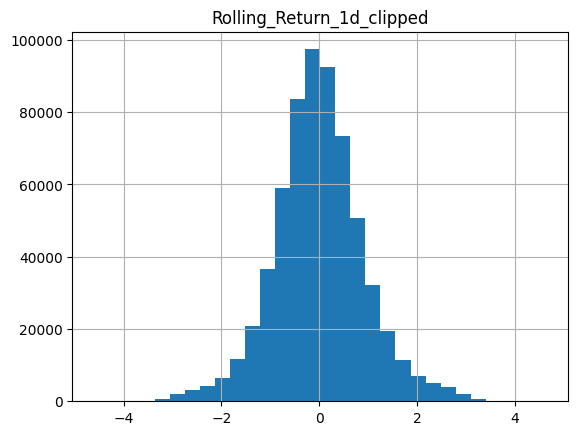

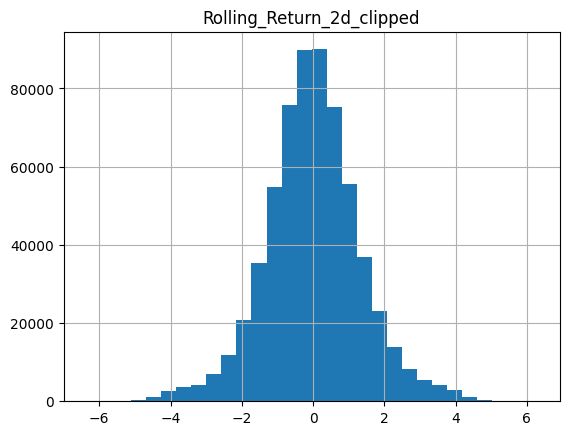

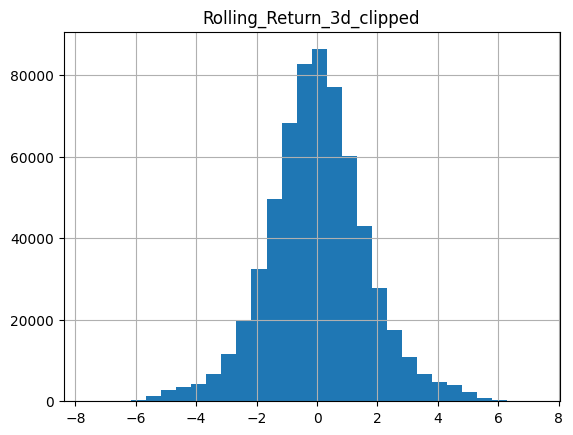

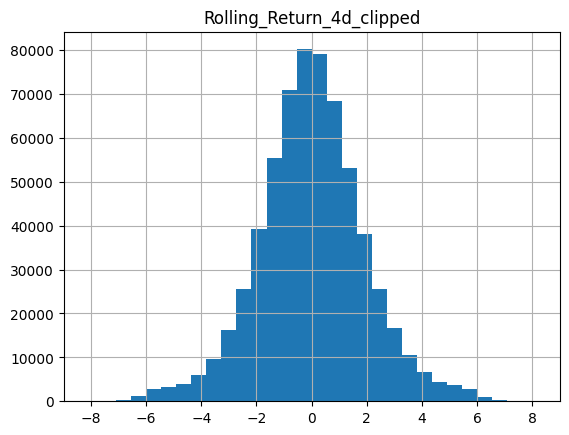

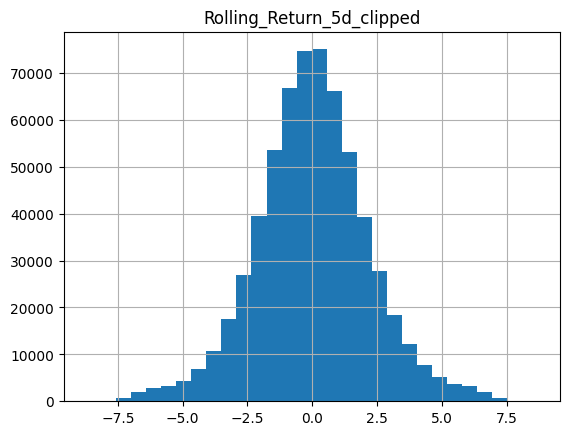

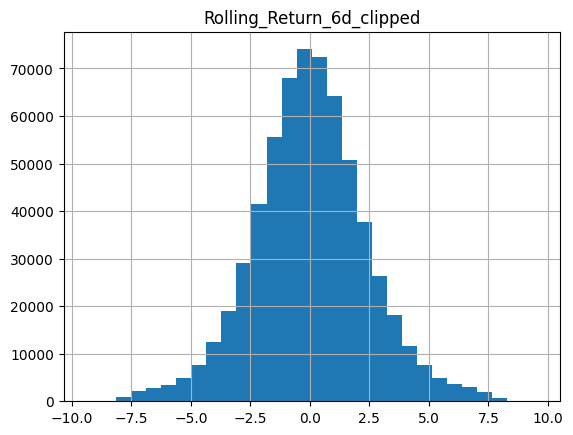

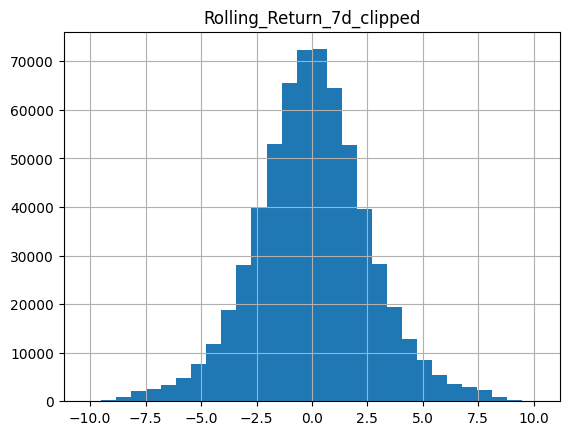

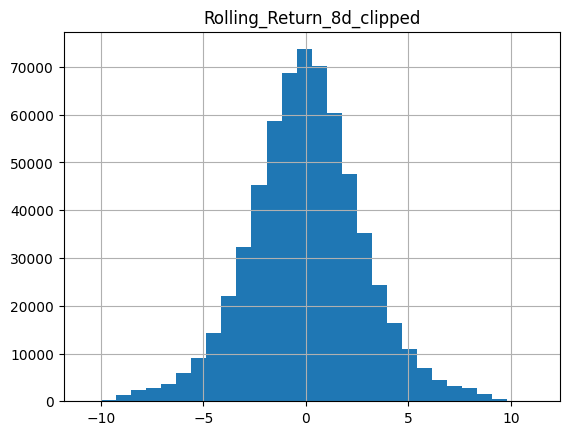

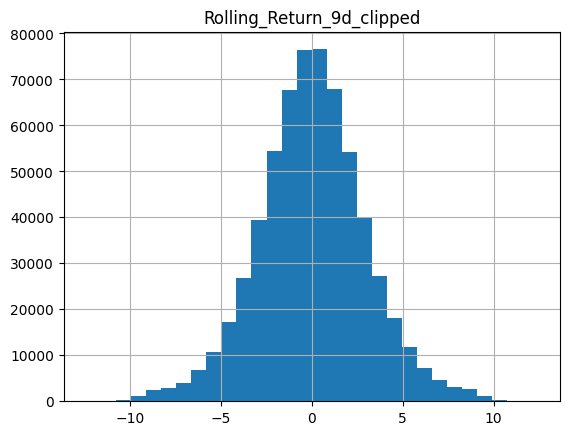

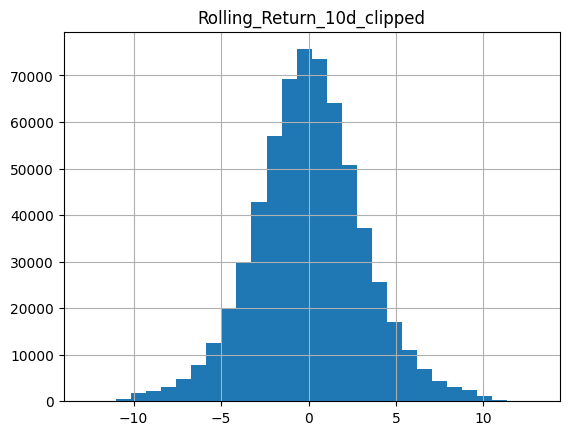

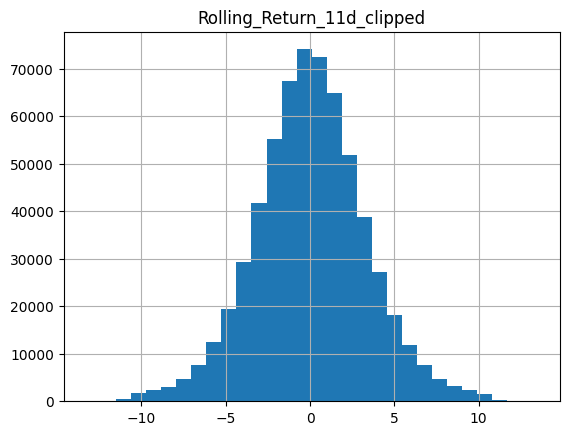

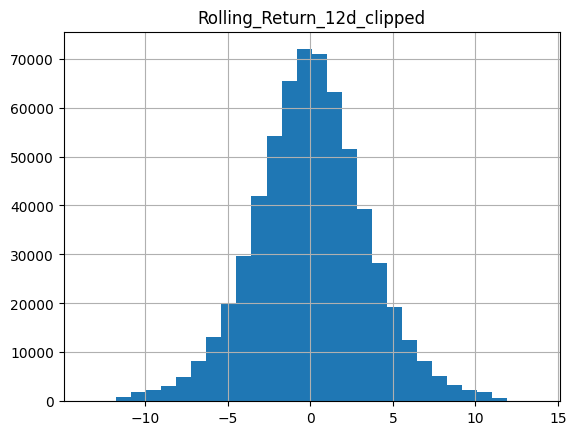

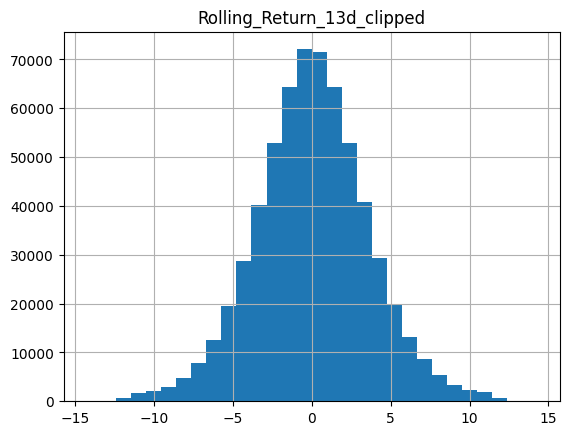

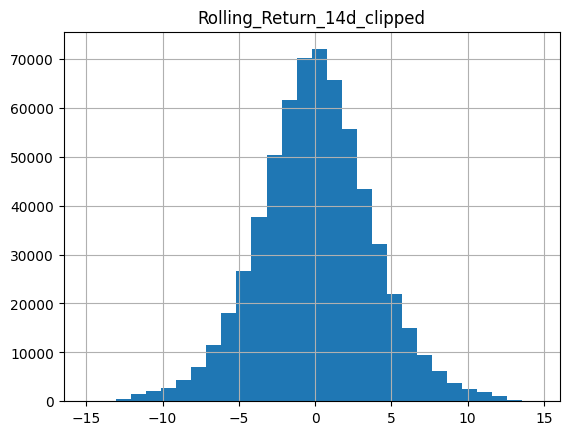

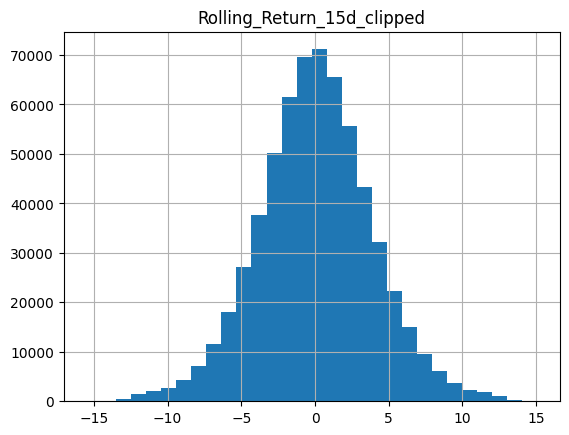

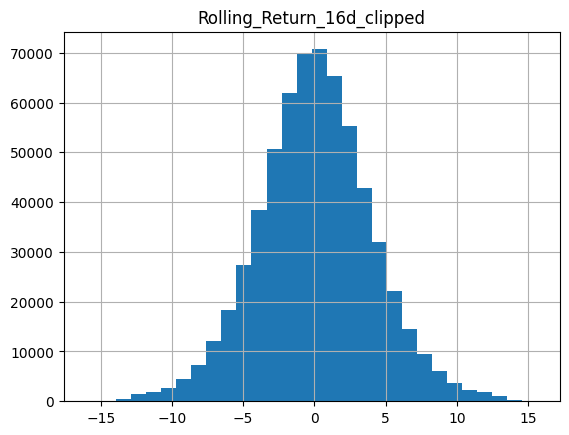

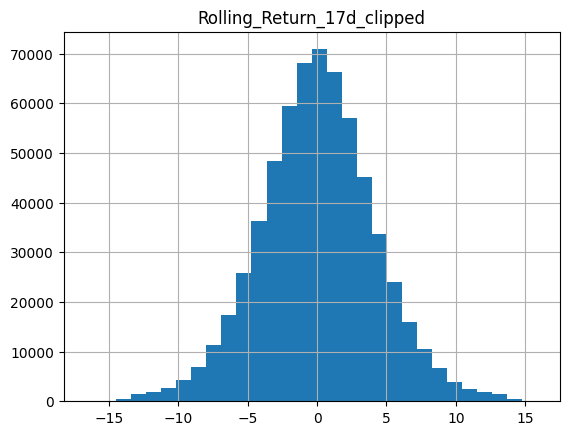

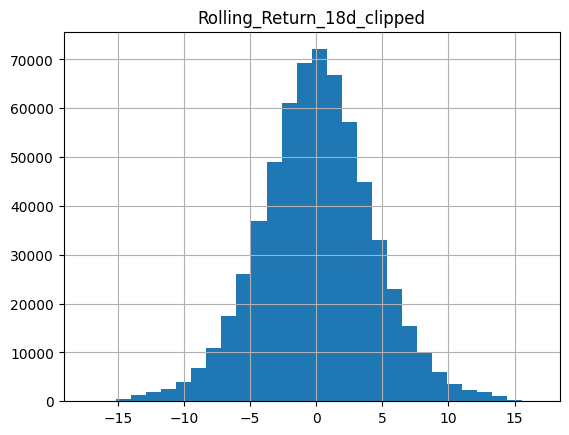

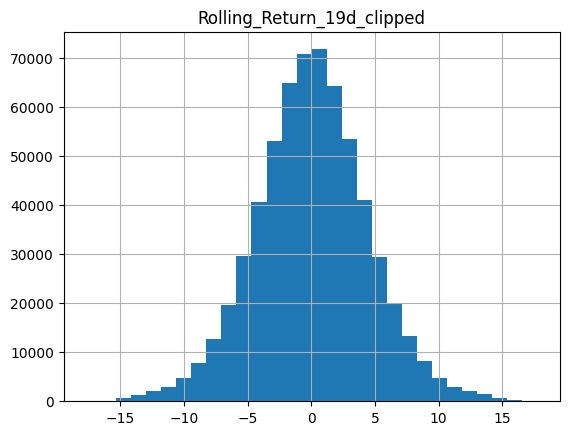

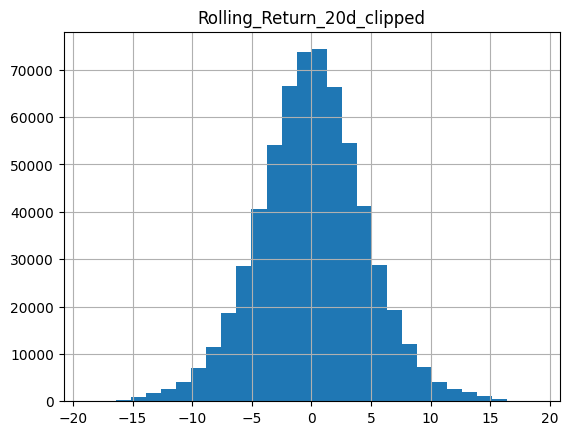

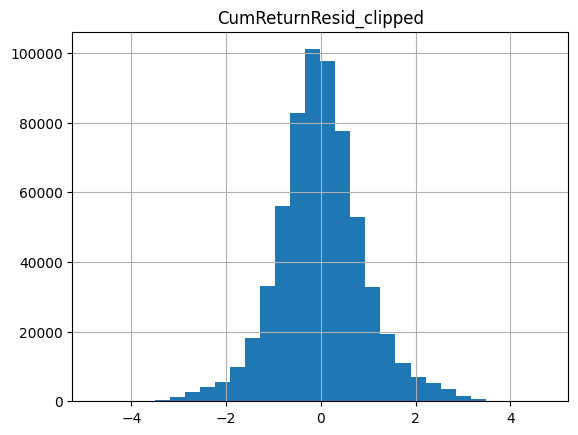

In [9]:
for col in clipped_returns:
    input_data[col].hist(bins = 30)
    plt.title(col) 
    plt.show()

#### CumReturnResid

## Target Var Distribution

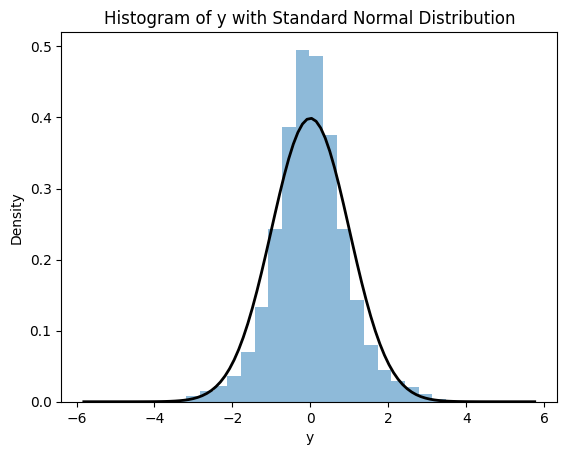

In [10]:
# Plot the histogram of 'y'
plt.hist(input_data.y, bins=30, alpha=0.5, density=True)

# Superimpose the standard normal distribution
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = np.exp(-x**2 / 2) / np.sqrt(2 * np.pi)
plt.plot(x, p, 'k', linewidth=2)

# plt.legend()
plt.title('Histogram of y with Standard Normal Distribution')
plt.xlabel('y')
plt.ylabel('Density')

# Show the plot
plt.show()

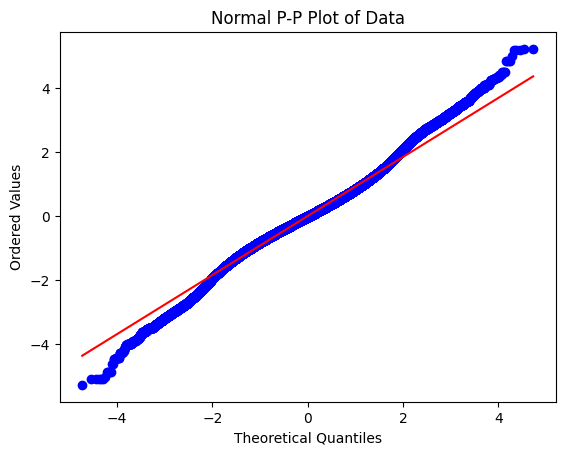

In [11]:
stats.probplot(input_data.y, dist="norm", plot=plt)
plt.title('Normal P-P Plot of Data')
plt.xlabel('Theoretical Quantiles')
plt.ylabel('Ordered Values')

# Show the plot
plt.show()

### Stationarity Test

In [12]:
target_by_id = input_data.reset_index().pivot(index = 'Id', columns = 'Date', values='y')

In [13]:
nonstationary = {}
for id in target_by_id.index:
    try:
        p_val = adfuller(target_by_id.loc[id].dropna())[1]
        if p_val > 0.05:
            nonstationary[id] = p_val
    except:
        pass

In [14]:
nonstationary

{'BBG000B9XG87': 0.8647448820522998,
 'BBG000BB8PG1': 0.3079941352776093,
 'BBG000BC2R71': 0.2629559821544569,
 'BBG000BF6756': 0.9688053069795641,
 'BBG000BF6RQ9': 0.48201316514446196,
 'BBG000BMDBZ1': 0.9943184896656087,
 'BBG000BMFD58': 0.44136095924521235,
 'BBG000BPL8X4': 0.11711398804721695,
 'BBG000BVF2M3': 0.08874909679245979,
 'BBG000C6W266': 0.08914327657923399,
 'BBG000CC53X1': 0.19400773477659738,
 'BBG000CWKRM9': 0.10318139936087439,
 'BBG000F5VVB6': 0.9971431659557719,
 'BBG000L4M7F1': 0.5187277254602997,
 'BBG000Q814S3': 0.19025346854676356,
 'BBG000QN5184': 0.38287779100665176,
 'BBG000W4G3B9': 0.06632197602660064,
 'BBG0018YXYX7': 0.5868110704656581,
 'GEN_EQ0000000003377626': 0.054574257201473436,
 'GEN_EQ0010156900001000': 0.23785498677202732,
 'GEN_EQ0010177100001000': 0.5124435810798048,
 'GEN_EQ0010509500001000': 0.6117745915497963}

## Target Var Distribution By Exchange

In [15]:
from itertools import combinations

In [21]:
p_vals = {}
for ex1, ex2 in combinations(input_data.MIC.unique(), 2):
    p_vals[(ex1, ex2)] = stats.ks_2samp(input_data.query('MIC == @ex1').y,input_data.query('MIC == @ex2').y).pvalue
    
exchanges = input_data.MIC.unique()
exchanges

exchanges_mapping = {
    'XNYS': 'New York Stock Exchange (NYSE)',
    'XNGS': 'NASDAQ Global Select Market',
    'XNMS': 'NASDAQ Global Market',
    'XASE': 'NYSE American (formerly American Stock Exchange, AMEX)'
}

In [19]:
target_by_id = target_by_id.dropna()

def diff_distribution_frac(input_data, exchange = None):
    query_df = input_data.query('MIC == @exchange') if exchange else input_data
    stock_pairs = combinations(query_df.index.get_level_values('Id').unique(), 2)
    p_vals = {}
    for id1, id2 in stock_pairs:
        try:
            p_vals[(id1, id2)] = stats.ks_2samp(target_by_id.loc[id1],target_by_id.loc[id2]).pvalue
        except:
            pass
       
    return len([v for _, v in p_vals.items() if v < 0.05]) / len(p_vals) if len(p_vals)  else np.nan

In [20]:
{e:diff_distribution_frac(input_data,e) for e in exchanges}

{'XNYS': 0.2089489235964542,
 'XNGS': 0.17162698412698413,
 'XNMS': nan,
 'XASE': nan}

In [22]:
diff_distribution_frac(input_data)

0.20537449971412236

In [ ]:
 stats.ks_2sap(input_data.query('MIC == @ex1').y,input_data.query('MIC == @ex2').y).

0.0014302520713997114

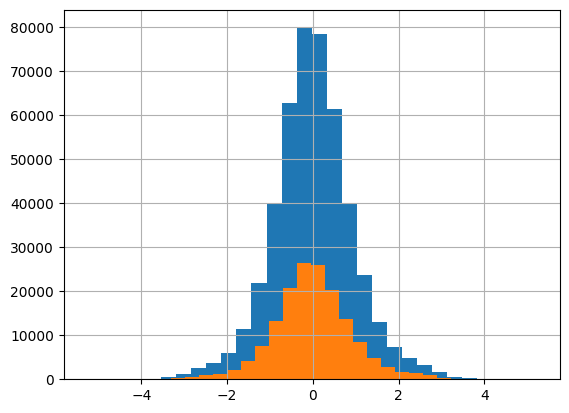

In [ ]:
for ex in input_data.MIC.unique():
    input_data.query('MIC == @ex').y.hist(bins=30)